## **PERTANYAAN BISNIS**

### **1. Kecamatan mana yang memiliki total volume sampah dikelola terbesar?**
### **2. Apakah kapasitas bank sampah berpengaruh terhadap volume sampah yang dikelola?**

### **IMPORT LIBRARY**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
# from geopy.geocoders import Nominati
from geopy.extra.rate_limiter import RateLimiter

#### **LOAD DATA**

In [28]:
data = pd.read_csv("D:/TUGAS KAMPUS SEMESTER 6/DICODING/Capstone/data_bank_sampah_mentah.csv")
data.head()

,data_bulan,data_tahun,nama,id_tps,alamat,kecamatan,kelurahan,jenis_fasilitas,thn_bangun,klasifikasi_struktur,klasifikasi_pengangkutan,tahun,status,kapasitas,vol_masuk,vol_dikelola,volume_sampah_diolah,vol_diangkut,waktu_angkut
0,3,2025,TPS Dinoyo,17.0,Jl. Siliwangi,Kec. Tegalsari,Kel. Keputran,TPS,0,TPS,compactor,NaN,aktif,28.0,28.0,28.0,28.0,28.0,1.0
1,3,2025,TPS Taman Ketampon,18.0,Jl. Taman Ketampon,Kec. Wonokromo,Kel. Darmo,TPS,0,TPS,compactor,NaN,aktif,23.0,23.0,23.0,23.0,23.0,1.0
2,3,2025,TPS Pasar Keputran,19.0,Jl. Keputran Utara,Kec. Tegalsari,Kel. Keputran,TPS,0,TPS,compactor,NaN,aktif,14.0,14.0,14.0,14.0,14.0,1.0
3,3,2025,TPS Tubanan,20.0,Jl. Tubanan,Kec. Tandes,Kel. Karangpoh,TPS,0,TPS,armroll,NaN,aktif,14.0,14.0,14.0,14.0,14.0,1.0
4,3,2025,TPS Karangpoh,21.0,Jl. Darmo Indah Barat II,Kec. Tandes,Kel. Karangpoh,TPS,0,TPS,armroll,NaN,aktif,14.0,14.0,14.0,14.0,14.0,1.0


#### **FILTER DATA STATUS = AKTIF**

In [29]:
df_aktif = data[data['status'] == 'aktif'][['nama','alamat','kelurahan','kecamatan','kapasitas','vol_masuk','vol_dikelola','volume_sampah_diolah','vol_diangkut']].rename(columns=str.capitalize)
df_non_aktif = data[data['status'] != 'aktif'][['nama','alamat','kelurahan','kecamatan','kapasitas','vol_masuk','vol_dikelola','volume_sampah_diolah','vol_diangkut']].rename(columns=str.capitalize)
print("=== Data Aktif ===")
print(len(df_aktif))

print("\n=== Data Selain Aktif ===")
print(len(df_non_aktif))

=== Data Aktif ===
229

=== Data Selain Aktif ===
4


#### **CEK DATA DENGAN SPASI BERLEBIH**

In [30]:
mask = (df_aktif['Nama'] != df_aktif['Nama'].str.strip()) | (df_aktif['Nama'].str.contains(r'\s{2,}', na=False))

print("Jumlah data dengan spasi berlebih:", mask.sum())
print(df_aktif[mask])

Jumlah data dengan spasi berlebih: 0
Empty DataFrame
Columns: [Nama, Alamat, Kelurahan, Kecamatan, Kapasitas, Vol_masuk, Vol_dikelola, Volume_sampah_diolah, Vol_diangkut]
Index: []


## **EXPLORATORY DATA ANALYSIS**

In [31]:
kolom_cek = [
    'Kapasitas',
    'Vol_masuk',
    'Vol_dikelola',
    'Volume_sampah_diolah',
    'Vol_diangkut',
]

print("=== Pengecekan nilai dengan akhiran .0 ===\n")

for kolom in kolom_cek:
    nilai = df_aktif[kolom].dropna()
    semua_belakang_nol = (nilai % 1 == 0).all()
    
    print(f"{kolom} ->", semua_belakang_nol)

=== Pengecekan nilai dengan akhiran .0 ===

Kapasitas -> False
Vol_masuk -> False
Vol_dikelola -> False
Volume_sampah_diolah -> False
Vol_diangkut -> False


In [32]:
print(df_aktif.isnull().sum())

Nama                     0
Alamat                   0
Kelurahan                0
Kecamatan                0
Kapasitas                0
Vol_masuk                1
Vol_dikelola             1
Volume_sampah_diolah     1
Vol_diangkut            30
dtype: int64


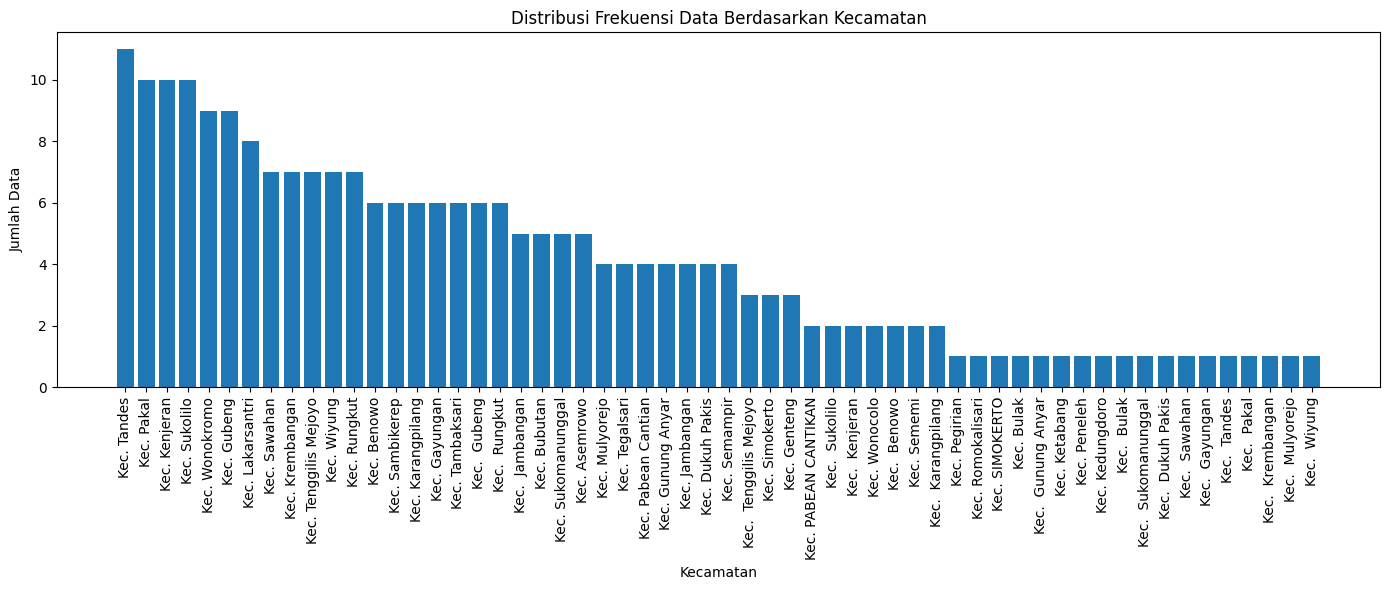

In [33]:
freq_kecamatan = data['kecamatan'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14,6))
plt.bar(freq_kecamatan.index, freq_kecamatan.values)

plt.title('Distribusi Frekuensi Data Berdasarkan Kecamatan')
plt.xlabel('Kecamatan')
plt.ylabel('Jumlah Data')

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

## **PREPROCESSING**

In [34]:
df_aktif = df_aktif.rename(columns={
    'Vol_masuk': 'Volume Masuk',
    'Vol_dikelola': 'Volume Dikelola',
    'Volume_sampah_diolah': 'Volume Sampah Diolah',
    'Vol_diangkut': 'Volume Diangkut'
})

df_aktif.head(2)

,Nama,Alamat,Kelurahan,Kecamatan,Kapasitas,Volume Masuk,Volume Dikelola,Volume Sampah Diolah,Volume Diangkut
0,TPS Dinoyo,Jl. Siliwangi,Kel. Keputran,Kec. Tegalsari,28.0,28.0,28.0,28.0,28.0
1,TPS Taman Ketampon,Jl. Taman Ketampon,Kel. Darmo,Kec. Wonokromo,23.0,23.0,23.0,23.0,23.0


In [35]:
kolom_float = [
    'Kapasitas',
    'Volume Masuk',
    'Volume Dikelola',
    'Volume Sampah Diolah',
    'Volume Diangkut'
]

df_aktif[kolom_float] = df_aktif[kolom_float].round(1)

In [36]:
df_aktif = df_aktif.fillna(0)
print(df_aktif.isnull().sum())

Nama                    0
Alamat                  0
Kelurahan               0
Kecamatan               0
Kapasitas               0
Volume Masuk            0
Volume Dikelola         0
Volume Sampah Diolah    0
Volume Diangkut         0
dtype: int64


#### **CLEANING KATA "KEL." & "KEC."**

In [37]:
df_aktif['Kelurahan'] = df_aktif['Kelurahan'].str.replace(r'(?i)^kel\.?\s*', '', regex=True)
df_aktif['Kecamatan'] = df_aktif['Kecamatan'].str.replace(r'(?i)^kec\.?\s*', '', regex=True)

df_aktif.head()

,Nama,Alamat,Kelurahan,Kecamatan,Kapasitas,Volume Masuk,Volume Dikelola,Volume Sampah Diolah,Volume Diangkut
0,TPS Dinoyo,Jl. Siliwangi,Keputran,Tegalsari,28.0,28.0,28.0,28.0,28.0
1,TPS Taman Ketampon,Jl. Taman Ketampon,Darmo,Wonokromo,23.0,23.0,23.0,23.0,23.0
2,TPS Pasar Keputran,Jl. Keputran Utara,Keputran,Tegalsari,14.0,14.0,14.0,14.0,14.0
3,TPS Tubanan,Jl. Tubanan,Karangpoh,Tandes,14.0,14.0,14.0,14.0,14.0
4,TPS Karangpoh,Jl. Darmo Indah Barat II,Karangpoh,Tandes,14.0,14.0,14.0,14.0,14.0


In [38]:
df_aktif.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229 entries, 0 to 232
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Nama                  229 non-null    object 
 1   Alamat                229 non-null    object 
 2   Kelurahan             229 non-null    object 
 3   Kecamatan             229 non-null    object 
 4   Kapasitas             229 non-null    float64
 5   Volume Masuk          229 non-null    float64
 6   Volume Dikelola       229 non-null    float64
 7   Volume Sampah Diolah  229 non-null    float64
 8   Volume Diangkut       229 non-null    float64
dtypes: float64(5), object(4)
memory usage: 17.9+ KB


#### **CLEANING FORMAT**

In [39]:
def format_text(x):
    if isinstance(x, str):

        x = re.sub(r'(?i)\btps\s*([0-9]+[A-Za-z]*)', r'TPS \1', x)
        x = re.sub(r'(?i)\bno\b(?!\.)', 'No.', x)
        x = re.sub(r'(?i)(?<!No\.\s)(\b\d+\b)', r'No. \1', x)

        def format_word(word):
            clean = re.sub(r'[^A-Za-z]', '', word)
            upper_clean = clean.upper()

            if upper_clean == 'TPS':
                return 'TPS'
            elif re.fullmatch(r'[IVXLCDM]+', upper_clean):
                return word.upper()
            elif re.fullmatch(r'[BCDFGHJKLMNPQRSTVWXYZ]{3}', upper_clean):
                return word.upper()
            else:
                return re.sub(r'[A-Za-z]+', lambda m: m.group(0).capitalize(), word, count=1)

        return ' '.join(format_word(w) for w in x.split())

    return x


df_aktif['Nama'] = df_aktif['Nama'].str.replace(
    r'(?i)\b(jl|jln|jalan)\.?\s*',
    '',
    regex=True
)

df_aktif['Nama'] = df_aktif['Nama'].str.replace(
    r'(?i)\b(jl\.?|jalan|kecamatan|kelurahan)\b',
    '',
    regex=True
)

df_aktif['Nama'] = df_aktif['Nama'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()


df_aktif['Alamat'] = df_aktif['Alamat'].str.replace(
    r'(?i)\b(jl|jln|jalan)[\.,]?\s*',
    'Jl. ',
    regex=True
)

df_aktif['Alamat'] = df_aktif['Alamat'].str.replace(
    r'Jl\.\s*,\s*',
    'Jl. ',
    regex=True
)

df_aktif['Alamat'] = df_aktif['Alamat'].str.replace(
    r'(?i)\b(kecamatan|kelurahan)\b\.?\s*',
    '',
    regex=True
)

df_aktif['Alamat'] = df_aktif['Alamat'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()


df_aktif = df_aktif.applymap(format_text)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14968\997899871.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_aktif = df_aktif.applymap(format_text)


In [40]:
def fix_nomor(text):
    if isinstance(text, str):
        text = re.sub(r'(?i)\bno\b(?!\.)', 'No.', text)
        text = re.sub(r'(?i)(?<!No\.\s)(\b\d+\b)', r'No. \1', text)
        text = re.sub(r'\s+', ' ', text).strip()

    return text

df_aktif['Alamat'] = df_aktif['Alamat'].apply(fix_nomor)

### **PERBAIKAN PENULISAN KELURAHAN & KECAMATAN**

In [41]:
df_aktif['Kelurahan'] = df_aktif['Kelurahan'].replace({
    'Tambaksarioso': 'Tambak Sarioso',
    'Waru Gunung' : 'Warugunung',
    'Petemn' : 'Petemon',
    'Swunggaling' : 'Sawunggaling'
})

df_aktif['Kecamatan'] = df_aktif['Kecamatan'].replace({
    'Karangpilang' : 'Karang Pilang',
    'Pabean Cantikan' : 'Pabean Cantian'
})

### **PERBAIKAN KELURAHAN DI KECAMATAN YANG SALAH**

In [42]:
perbaikan_kecamatan = {
    'Babat Jerawat': 'Pakal',
    'Keputran' : 'Tegalsari',
    'Ngagel Rejo' : 'Wonokromo',
    'Penjaringan Sari' : 'Rungkut'
    
}

df_aktif['Kecamatan'] = df_aktif.apply(
    lambda x: perbaikan_kecamatan[x['Kelurahan']]
    if x['Kelurahan'] in perbaikan_kecamatan
    else x['Kecamatan'],
    axis=1
)

#### **SORTING DATA**

In [43]:
df_aktif = df_aktif.sort_values(by=['Kecamatan', 'Kelurahan', 'Alamat'])
df_aktif.head()

,Nama,Alamat,Kelurahan,Kecamatan,Kapasitas,Volume Masuk,Volume Dikelola,Volume Sampah Diolah,Volume Diangkut
50,TPS Pasar Asemrowo,Jl. Asemraya,Asemrowo,Asemrowo,8.0,8.0,8.0,8.0,8.0
51,TPS Jayamix,Jl. Dupak Rukun,Asemrowo,Asemrowo,28.0,28.0,28.0,28.0,28.0
52,TPS Genting,Jl. Genting,Asemrowo,Asemrowo,14.0,14.0,14.0,14.0,14.0
66,Landasan Tambak Asri,Jl. Tambak Asri,Genting Kalianak,Asemrowo,14.0,14.0,14.0,14.0,14.0
53,TPS Greges,Jl. Greges Kalianak,Tambak Sarioso,Asemrowo,14.0,14.0,14.0,14.0,14.0


### **AMBIL TITIK LATITUDE & LONGITUDE**

In [44]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="geo_kelurahan_kecamatan")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

cache_koordinat = {}

def ambil_koordinat(row):

    key = f"{row['Kelurahan']}, {row['Kecamatan']}"

    if key in cache_koordinat:
        return cache_koordinat[key]

    try:
        lokasi = f"{row['Kelurahan']}, {row['Kecamatan']}, Surabaya, Jawa Timur, Indonesia"
        hasil = geocode(lokasi)

        if hasil:
            cache_koordinat[key] = (hasil.latitude, hasil.longitude)
        else:
            cache_koordinat[key] = (None, None)

    except:
        cache_koordinat[key] = (None, None)

    return cache_koordinat[key]

df_aktif[['Latitude', 'Longitude']] = df_aktif.apply(
    ambil_koordinat,
    axis=1,
    result_type='expand'
)

In [45]:
df_aktif.head(2)

,Nama,Alamat,Kelurahan,Kecamatan,Kapasitas,Volume Masuk,Volume Dikelola,Volume Sampah Diolah,Volume Diangkut,Latitude,Longitude
50,TPS Pasar Asemrowo,Jl. Asemraya,Asemrowo,Asemrowo,8.0,8.0,8.0,8.0,8.0,-7.243424,112.703427
51,TPS Jayamix,Jl. Dupak Rukun,Asemrowo,Asemrowo,28.0,28.0,28.0,28.0,28.0,-7.243424,112.703427


#### **PENGECEKAN DUPLIKAT DATA**

In [46]:
duplikat = df_aktif[df_aktif.duplicated()]

print("Jumlah data duplikat:", duplikat.shape[0])
print(duplikat)

Jumlah data duplikat: 0
Empty DataFrame
Columns: [Nama, Alamat, Kelurahan, Kecamatan, Kapasitas, Volume Masuk, Volume Dikelola, Volume Sampah Diolah, Volume Diangkut, Latitude, Longitude]
Index: []


## **TRANSFORM DATA**

#### **SIMPAN DATA CLEAN**

In [48]:
# df_aktif.to_csv("data_bank_sampah_clean.csv", index=False)

#### **SIMPAN KE JSON**

In [49]:
# data_clean = pd.read_csv("D:/TUGAS KAMPUS SEMESTER 6/DICODING/Capstone/data_bank_sampah_clean.csv")
# data_clean

In [50]:
# data_clean.to_json("data_bank_sampah_clean.json", orient="records", force_ascii=False, indent=2)

## **EXPLONATORY DATA ANALYSIS**

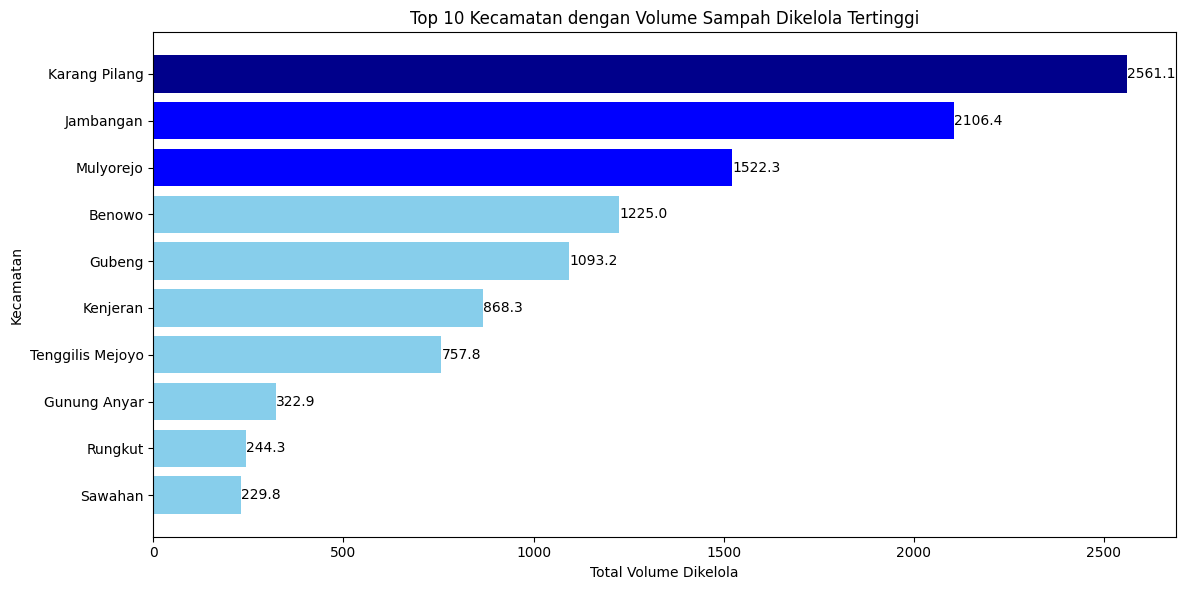

In [51]:
kolom_numerik = [
    "Volume Masuk",
    "Volume Dikelola",
    "Volume Sampah Diolah",
    "Volume Diangkut"
]

for kolom in kolom_numerik:
    df_aktif[kolom] = pd.to_numeric(df_aktif[kolom], errors='coerce')

volume_kecamatan = (
    df_aktif.groupby("Kecamatan")["Volume Dikelola"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

colors = []

for i in range(len(volume_kecamatan)):
    if i == 0:
        colors.append("darkblue")  
    elif i in [1, 2]:
        colors.append("blue") 
    else:
        colors.append("skyblue")

volume_kecamatan = volume_kecamatan[::-1]
colors = colors[::-1]

plt.figure(figsize=(12,6))

bars = plt.barh(
    volume_kecamatan.index,
    volume_kecamatan.values,
    color=colors
)

for bar in bars:
    xval = bar.get_width()
    plt.text(
        xval,
        bar.get_y() + bar.get_height()/2,
        round(xval, 1),
        va='center',
        ha='left'
    )

plt.title("Top 10 Kecamatan dengan Volume Sampah Dikelola Tertinggi")
plt.xlabel("Total Volume Dikelola")
plt.ylabel("Kecamatan")

plt.tight_layout()
plt.show()

Berdasarkan grafik Top 10 Kecamatan dengan Volume Sampah Dikelola Tertinggi, **Kecamatan Karang Pilang memiliki volume sampah dikelola paling tinggi** dengan nilai sekitar 2561.1, diikuti oleh Jambangan dan Mulyorejo, yang menunjukkan bahwa ketiga kecamatan tersebut memiliki aktivitas pengelolaan sampah yang lebih optimal dibanding wilayah lainnya. Terlihat pula adanya selisih cukup besar antara tiga kecamatan teratas dengan kecamatan lain, sehingga mengindikasikan ketimpangan kapasitas maupun efektivitas pengelolaan sampah antar kecamatan. Sementara itu, kecamatan seperti Rungkut dan Sawahan memiliki volume pengelolaan yang relatif rendah, yang dapat disebabkan oleh keterbatasan fasilitas, kapasitas operasional, maupun tingkat partisipasi masyarakat dalam pengelolaan sampah.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14968\2583055761.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("Kategori Kapasitas")["Volume Dikelola"]


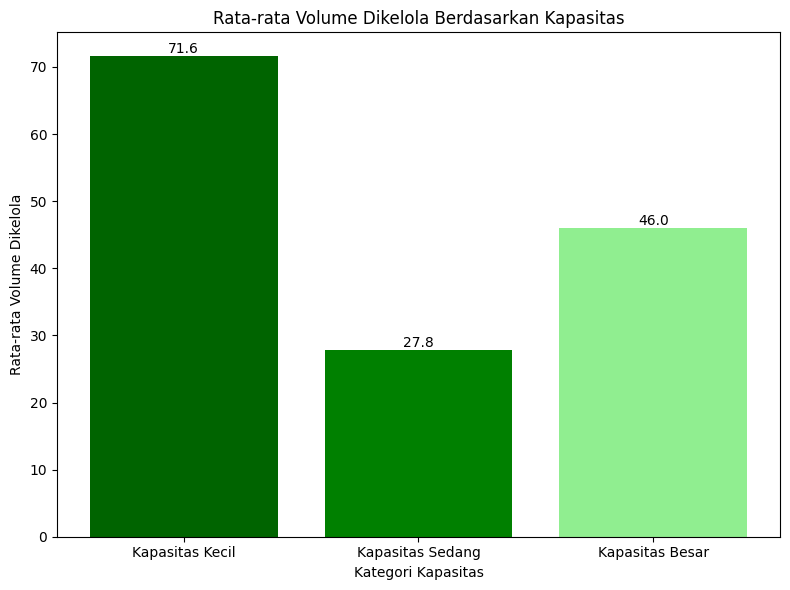

In [53]:
df_aktif["Kapasitas"] = pd.to_numeric(df_aktif["Kapasitas"], errors='coerce')
df_aktif["Volume Dikelola"] = pd.to_numeric(df_aktif["Volume Dikelola"], errors='coerce')

df_clean = df_aktif.dropna(subset=["Kapasitas", "Volume Dikelola"])

df_clean["Kategori Kapasitas"] = pd.cut(
    df_clean["Kapasitas"],
    bins=3,
    labels=["Kapasitas Kecil", "Kapasitas Sedang", "Kapasitas Besar"]
)

rata_volume = (
    df_clean.groupby("Kategori Kapasitas")["Volume Dikelola"]
    .mean()
)

colors = ["darkgreen", "green", "lightgreen"]

plt.figure(figsize=(8,6))

bars = plt.bar(
    rata_volume.index,
    rata_volume.values,
    color=colors
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 1),
        ha='center',
        va='bottom'
    )

plt.title("Rata-rata Volume Dikelola Berdasarkan Kapasitas")
plt.xlabel("Kategori Kapasitas")
plt.ylabel("Rata-rata Volume Dikelola")

plt.tight_layout()
plt.show()

Berdasarkan grafik rata-rata volume dikelola berdasarkan kapasitas, terlihat bahwa bank sampah dengan kapasitas kecil justru memiliki rata-rata volume dikelola tertinggi sebesar 71.6, lebih tinggi dibanding kapasitas besar sebesar 46.0 maupun kapasitas sedang sebesar 27.8. Hal ini menunjukkan bahwa kapasitas yang besar tidak selalu menjamin tingginya volume pengelolaan sampah. Kondisi tersebut mengindikasikan adanya kemungkinan bahwa beberapa bank sampah dengan kapasitas besar belum dimanfaatkan secara optimal, sedangkan bank sampah berkapasitas kecil cenderung lebih aktif atau lebih efisien dalam mengelola sampah yang masuk.